Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [1]:
import time

print(time.ctime(time.time()))

Mon Nov 27 17:21:57 2023


In [2]:
import sys
sys.path.insert(0, "../../processing/")

In [67]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools_xr import latlon2uv_dir

In [4]:
# version_information

In [5]:
print(xr.__version__)

2023.6.0


# Parameters:

In [6]:
url_drifter = "drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"
drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 
diff_time_thres = 3600 # [s] 1h # Will be different for SVP, higher as time res. is 1hr

temp_res = 600. # Specifying seconds 
# Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
# and SVP-B (1h))

# n_window = 12 # we leave like this for now

# CARTHE example

# 1. Loading the data:

In [7]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [8]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
else:
    print('Hereon is the same, add option, SVP missing temp , press , BAT_status different')
    fsdfs

In [9]:
url = url_root + url_drifter + url_vars
 
print(url)

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


In [10]:
# Load file
ds = xr.open_dataset(url)


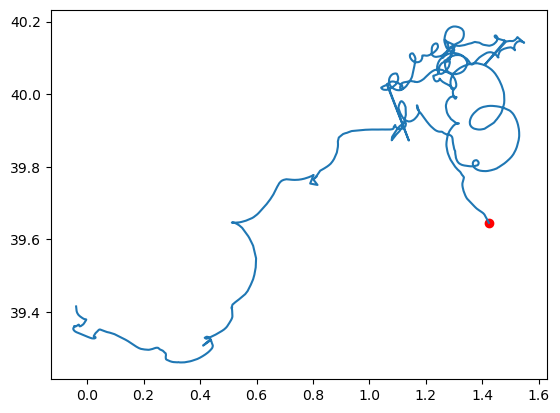

In [11]:

plt.plot(ds.LON, ds.LAT)
plt.scatter(ds.LON[0], ds.LAT[0], c='r')

# 2. Processing:

In [12]:
# Checking time interval:

print(ds.time[0].data)
print(ds.time[1].data)

# --> Should be: 
# 10 mins freq. for CARTHE
# 5 mins HEREON
# 1h SVP-B

2023-04-26T10:16:51.000000000
2023-04-26T10:26:48.000000000


## 2.1. Identifying large time gaps (to kill drifter traj trash)

### 1 hour:

In [13]:
diff_time_thres = 3600 # [s] 1h

In [14]:
dt_drif = ds.time.diff("time").dt.seconds

In [15]:
# just using np.where, find cleaner method with array to find indices:

In [16]:
inds_trash = np.where(dt_drif > diff_time_thres)[0]
inds_trash

array([3295, 3299, 3316, 3326, 3333, 3334, 3343, 3344, 3350, 3354, 3363,
       3365, 3370, 3450, 3560, 3568, 3584, 3589, 3590, 3591, 3597])

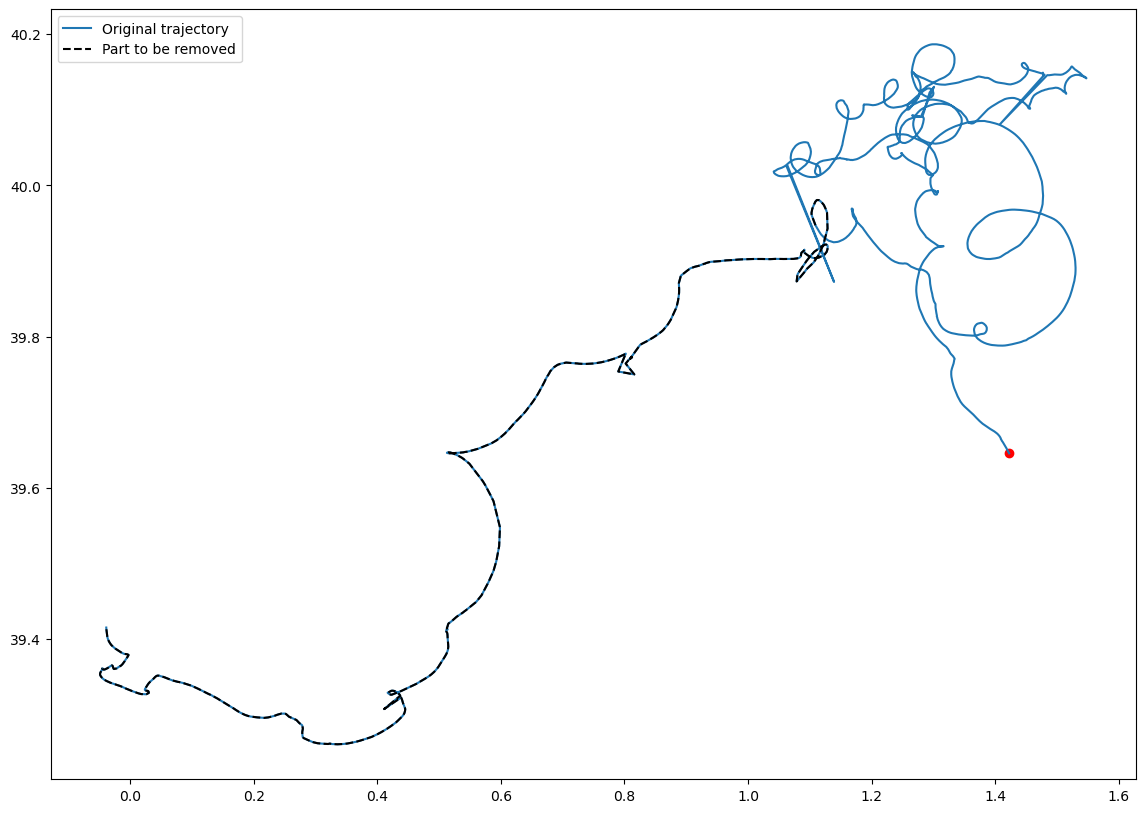

In [17]:
if inds_trash.size > 0: 
    plt.figure(figsize=(14,10))
    plt.plot(ds.LON, ds.LAT, label='Original trajectory')
    plt.scatter(ds.LON[0], ds.LAT[0], c='r')
    plt.plot(ds.LON[inds_trash[0]::], ds.LAT[inds_trash[0]::], '--k', label='Part to be removed')
    plt.legend()
else:
    print(f'Nothing to plot, no gap bigger than {diff_time_thres/3600} hours')

# --> we cut the traj. from the green part, although it looks good, something to revisit!

# 2 hours cut:

In [18]:
diff_time_thres = 3600 * 2 # [s] 1h

In [19]:
dt_drif = ds.time.diff("time").dt.seconds

In [20]:
inds_trash = np.where(dt_drif > diff_time_thres)[0]
inds_trash

array([3316, 3333, 3334, 3343])

In [21]:
if inds_trash.size > 0: 
    ds01 = ds.where(ds.time<ds.time[inds_trash[0]+2], drop=True) # to improve 
    # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
elif inds_trash.size == 0:
    ds01 = ds.copy()
else:
    print('Problem')
    fsdgsdfg

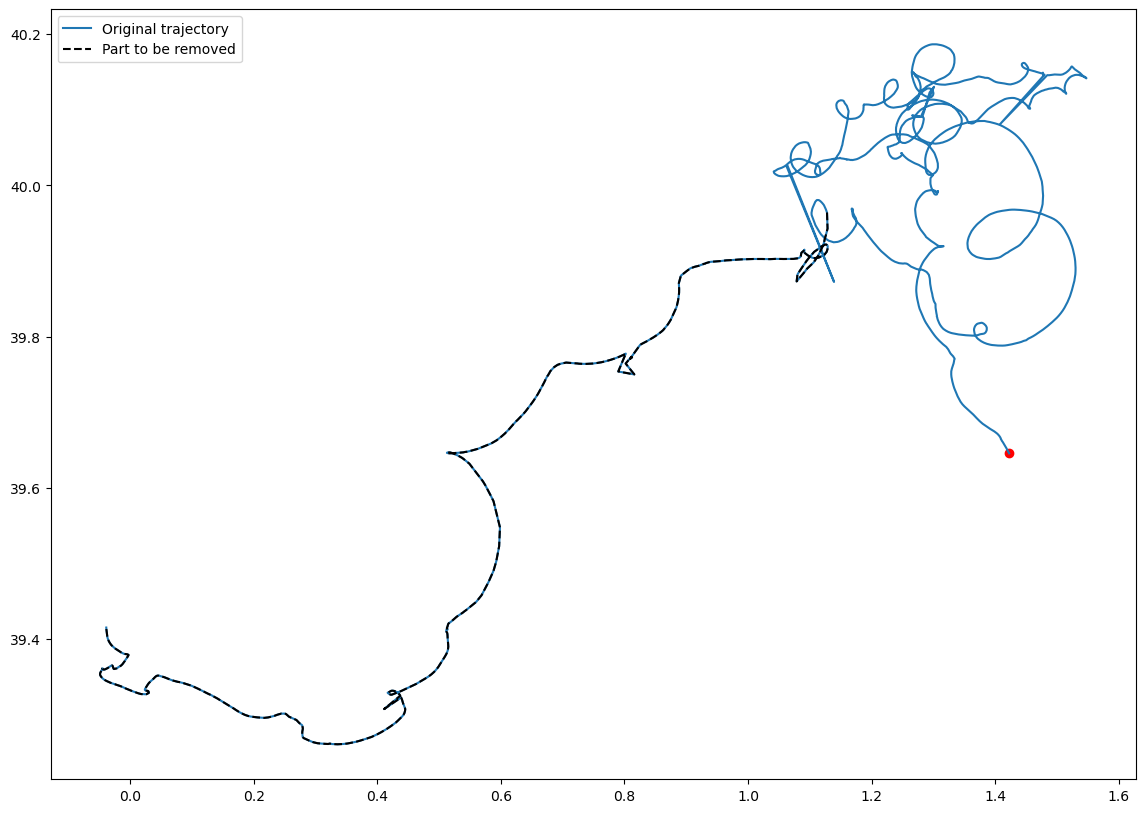

In [22]:
if inds_trash.size > 0: 
    plt.figure(figsize=(14,10))
    plt.plot(ds.LON, ds.LAT, label='Original trajectory')
    plt.scatter(ds.LON[0], ds.LAT[0], c='r')
    plt.plot(ds.LON[inds_trash[0]::], ds.LAT[inds_trash[0]::], '--k', label='Part to be removed')
    plt.legend()
else:
    print(f'Nothing to plot, no gap bigger than {diff_time_thres/3600} hours')

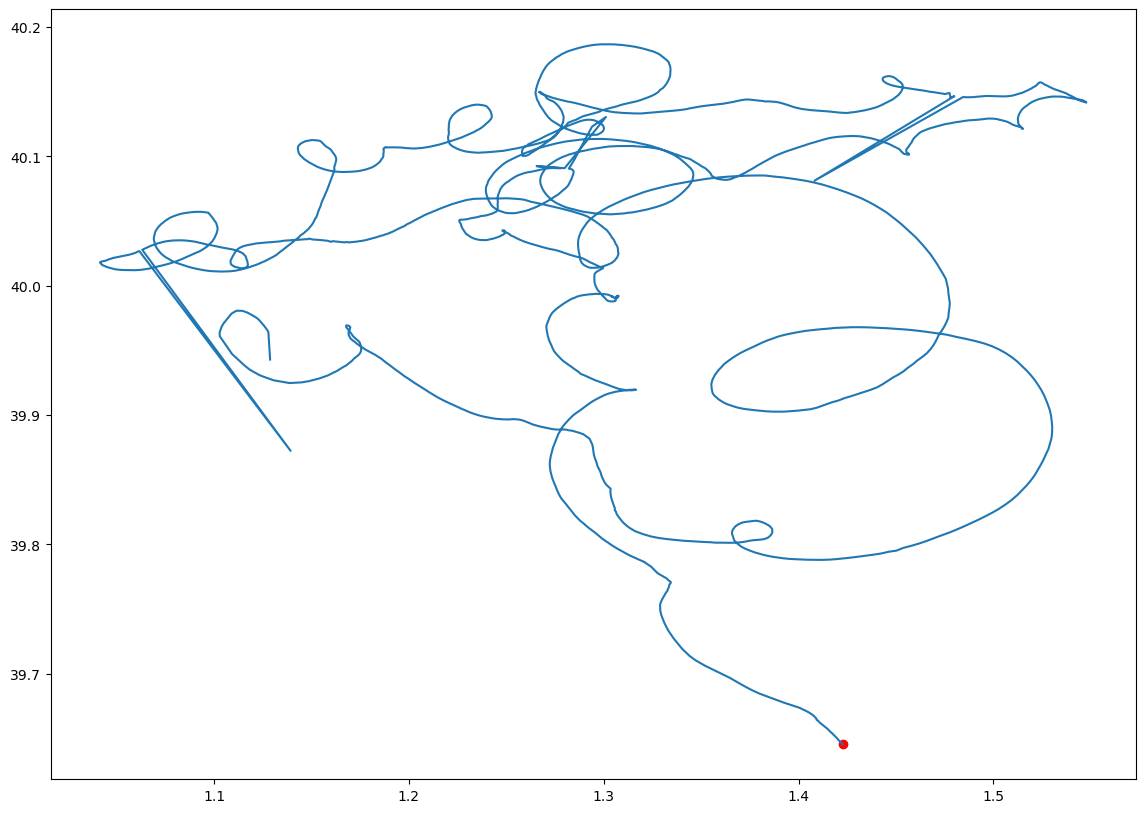

In [23]:
plt.figure(figsize=(14,10))
plt.plot(ds01.LON, ds01.LAT)
plt.scatter(ds01.LON[0], ds01.LAT[0], c='r')

## 2.2. Resampling to regular 10 mins. intervals:
(constant 10 mins and "o'clock" times)

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.

In [24]:
ds01 = ds01.reset_coords("LON")
ds01 = ds01.reset_coords("LAT")

In [25]:
ds01

<xarray.Dataset>
Dimensions:     (time: 3318)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-26T10:16:51 ... 2023-05-20T03:0...
    DEPTH       float64 0.6
Data variables:
    trajectory  (time) object b'drifter-carthe006_ime-carthe001_L0' ... b'dri...
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.65 39.65 39.65 39.65 ... 39.97 39.96 39.94
    LON         (time) float64 1.423 1.422 1.422 1.421 ... 1.127 1.128 1.129
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

### 2.2.2. Resampling:

In [26]:
ds02 = ds01.resample(time=f"{int(temp_res)}s").interpolate("linear") # xarray resample works very differently from pandas


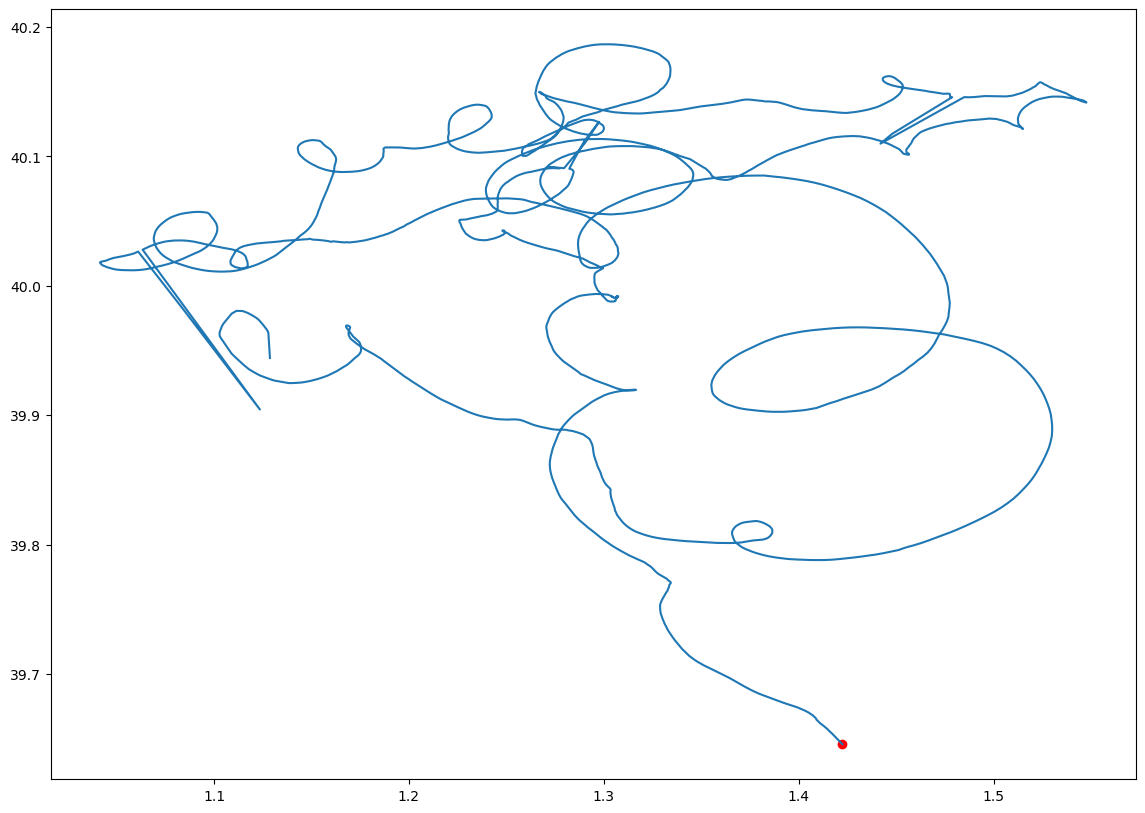

In [27]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')

# --> spikes now smaller but still present
# To improve: maybe better to remove spikes with lon and lat (thres 0.02?) before resampling so that spike not spread

## 2.3. Calculate forward and backward velocities

blabla bla boundary conditions, back (t-1) , and forward (vel at t+1) calculated
# --> Dani

In [28]:
ufor, vfor, uvabsfor   = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback, uvabsback = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'back')

In [29]:
# Add variables to the dataset
ds02 = ds02.assign(U=(ufor+uback)*0.5)
ds02 = ds02.assign(V=(vfor+vback)*0.5)
print(list(ds02.keys()))

['BAT_STATUS', 'LAT', 'LON', 'trajectory', 'U', 'V']


In [30]:
ds02.U.values

array([        nan, -0.0297894 , -0.03263608, ..., -0.03263608,
       -0.0297894 ,         nan])

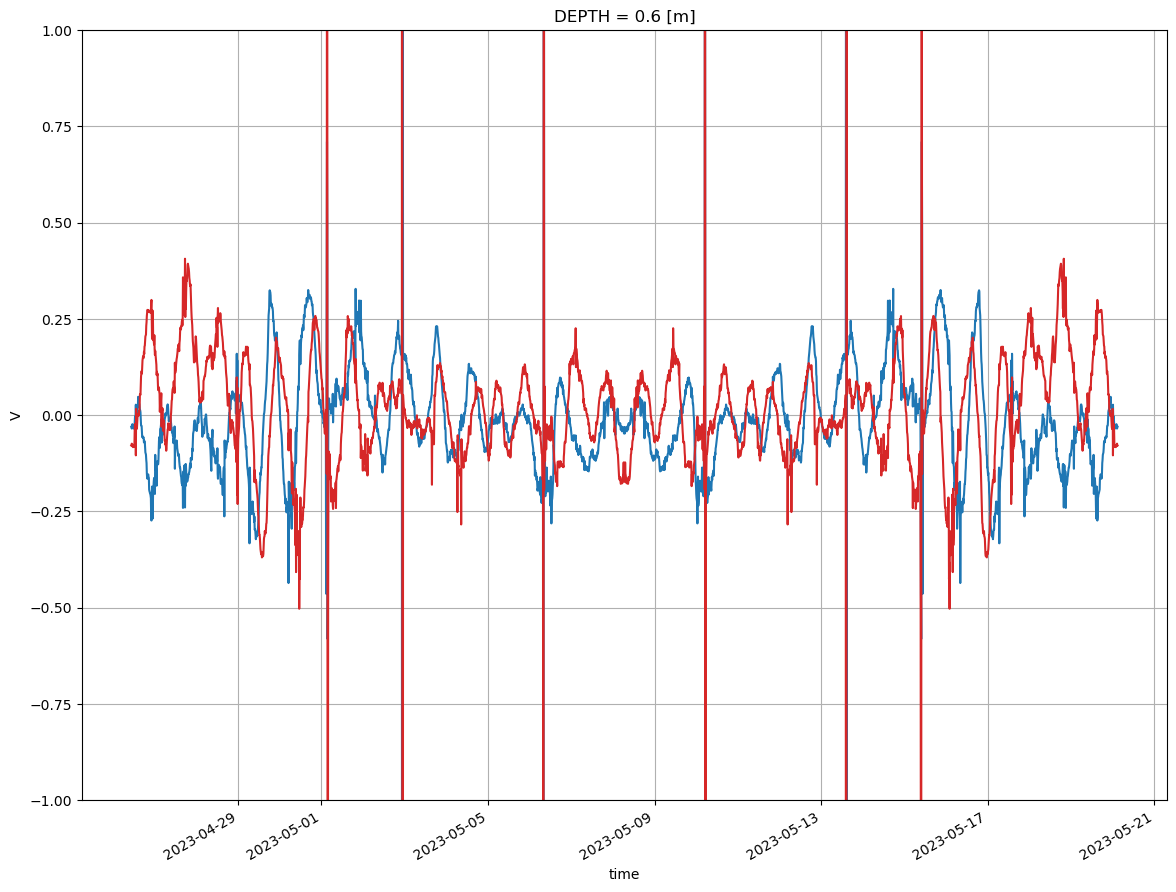

In [31]:
ds02.U.plot(figsize=(14,10))
ds02.V.plot(c='C3')
plt.ylim([-1, 1])
plt.grid()

# --> peaks not in phase, ok?

## 2.4. Spike cleaning:



Cleaning spikes now based on velocity thresholds(absolute velocity (speed))

In [32]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

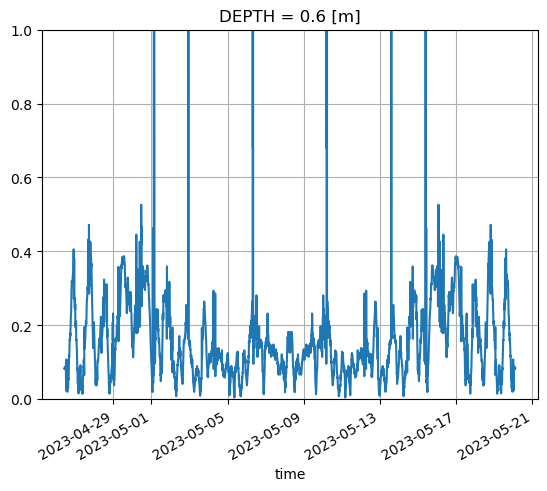

In [33]:
abs_vel.plot()
plt.ylim([0,1])
plt.grid()

Based on above plot we choose 0.8 m/s.

To improve:
- big spike cleaning with lon and lat thres. before resmpling
- do a moving vel. thres.
- would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

In [34]:
vel_thres = 0.8 # m/s 

In [35]:
ds03 = ds02.where(abs_vel < vel_thres)

In [36]:
abs_vel_new = (ds03.U**2 + ds03.V**2)**0.5

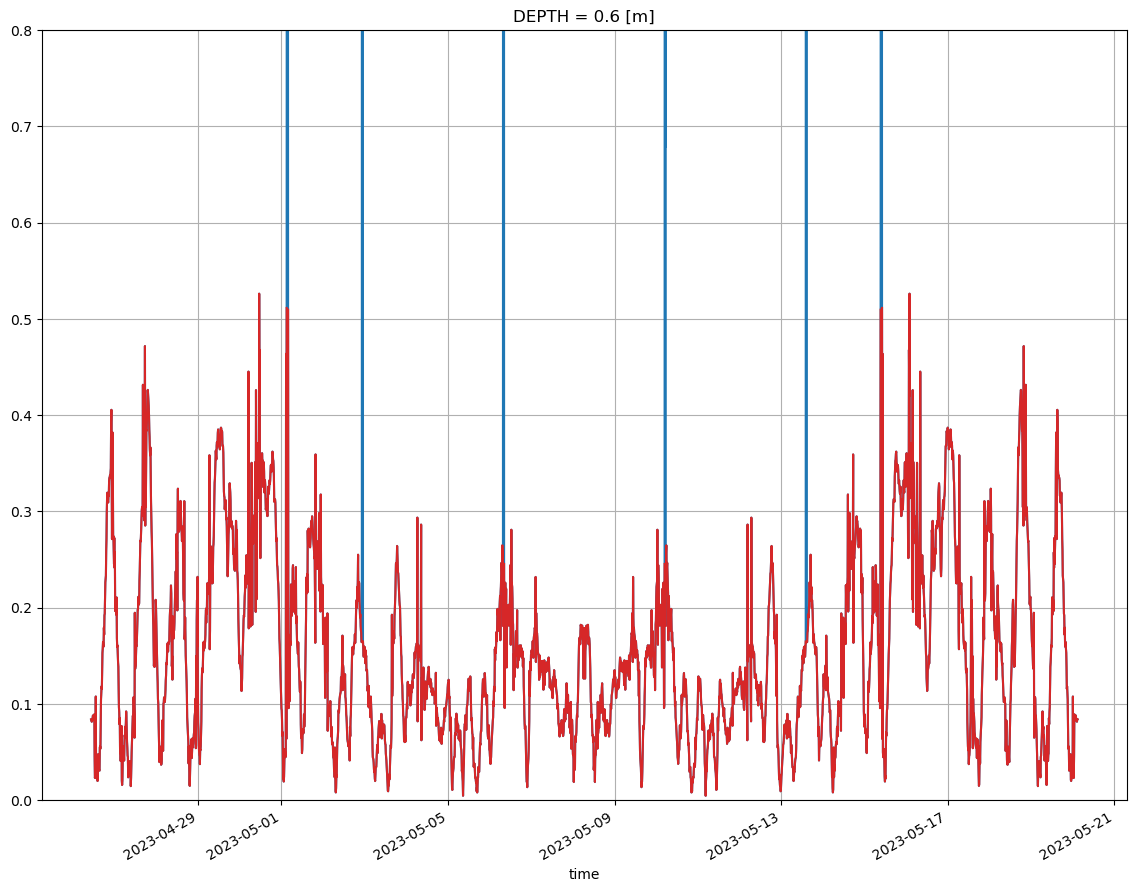

In [37]:
abs_vel.plot(figsize=(14,10))
abs_vel_new.plot(c='C3')
plt.ylim([0,0.8])
plt.grid()

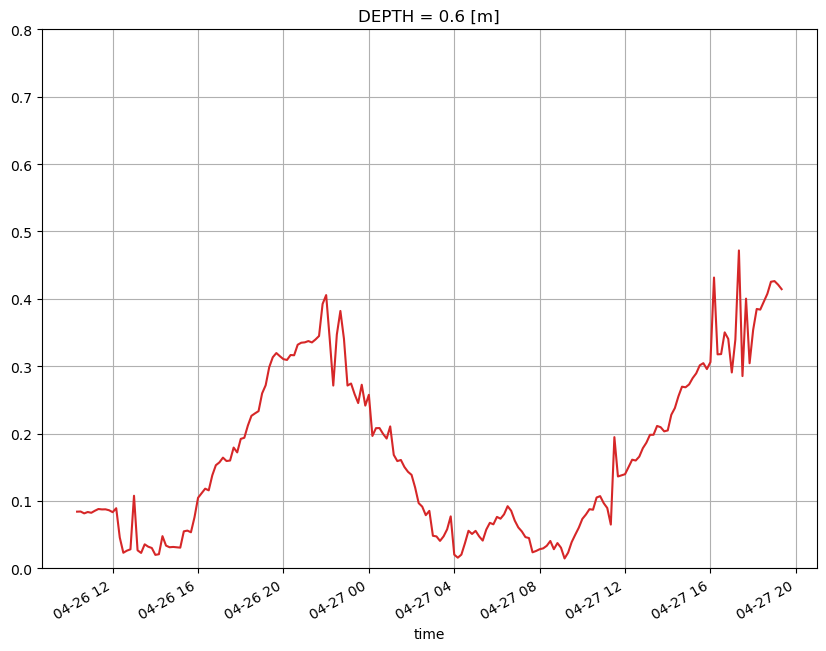

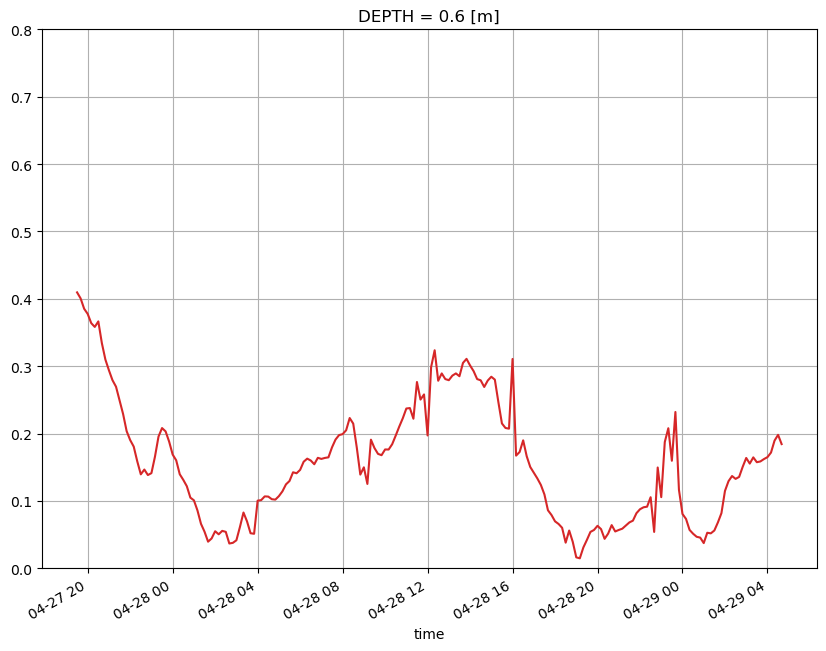

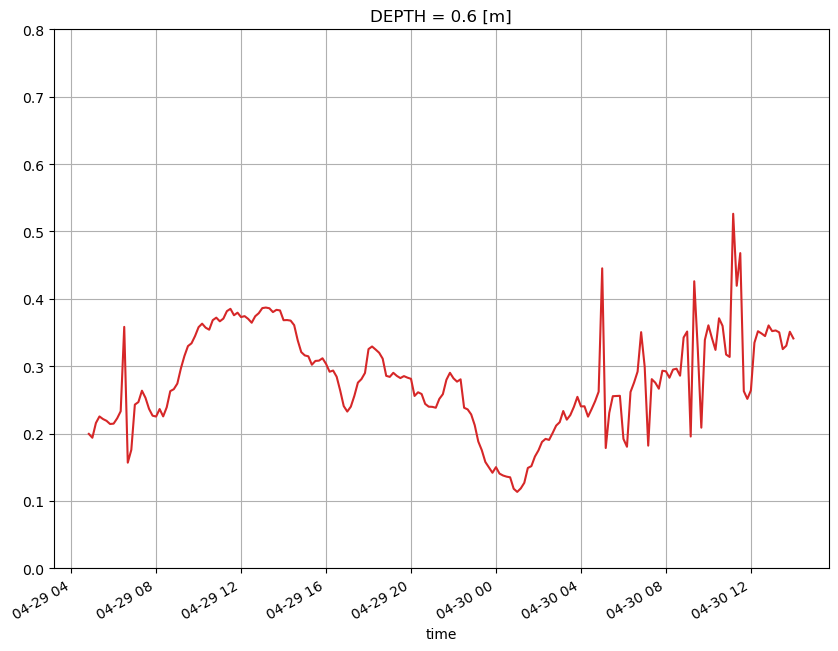

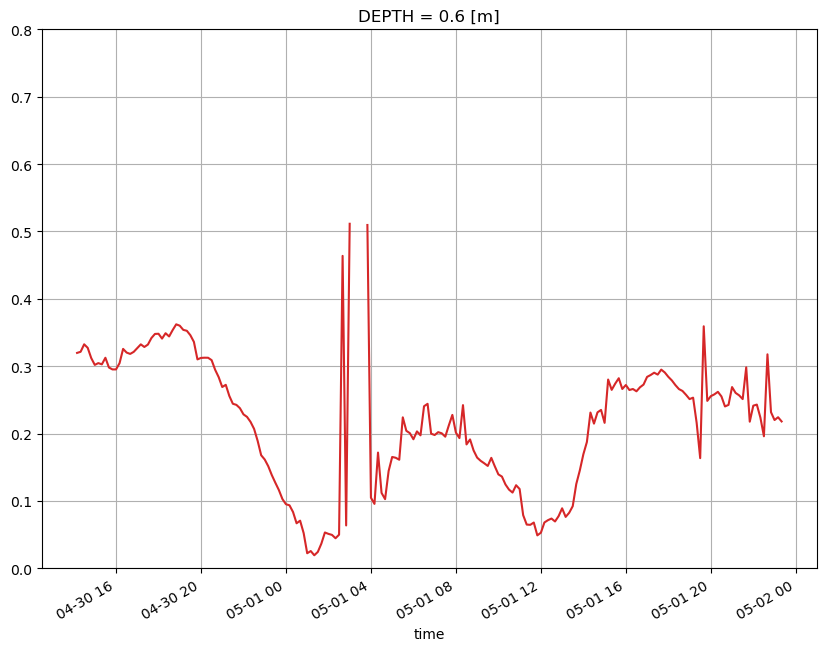

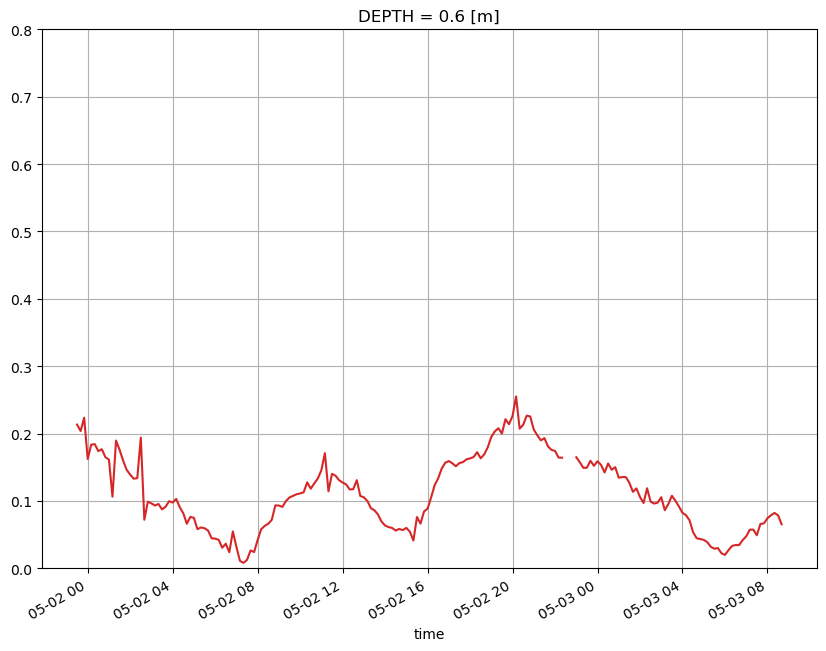

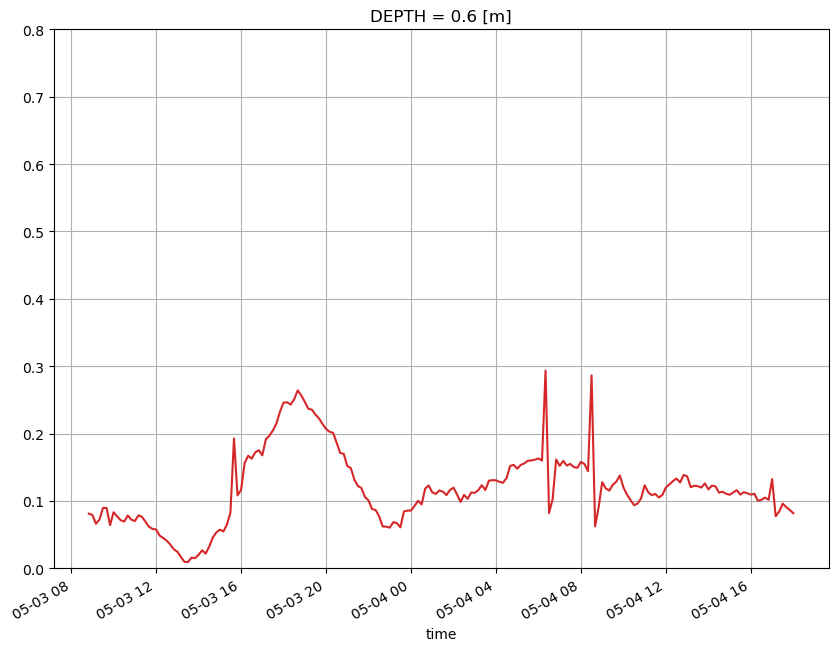

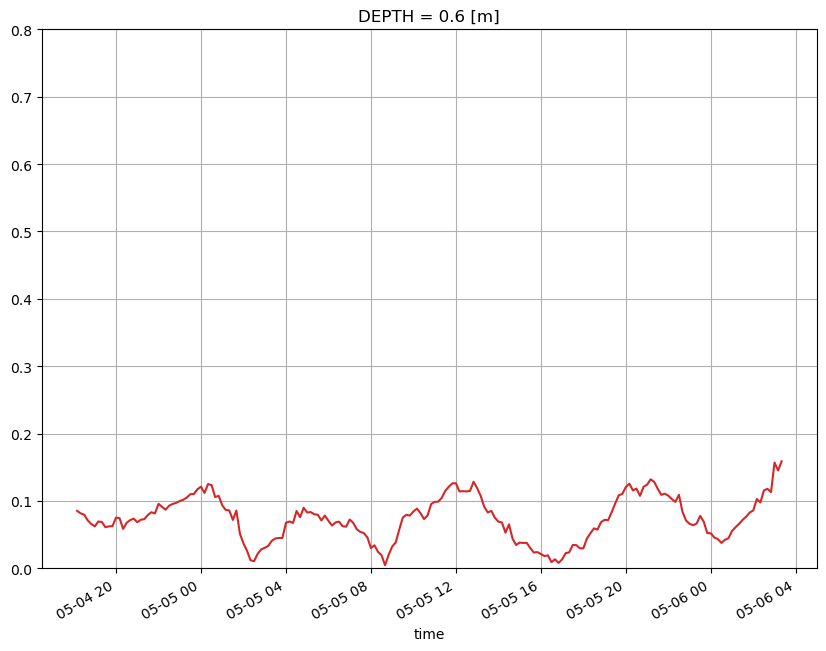

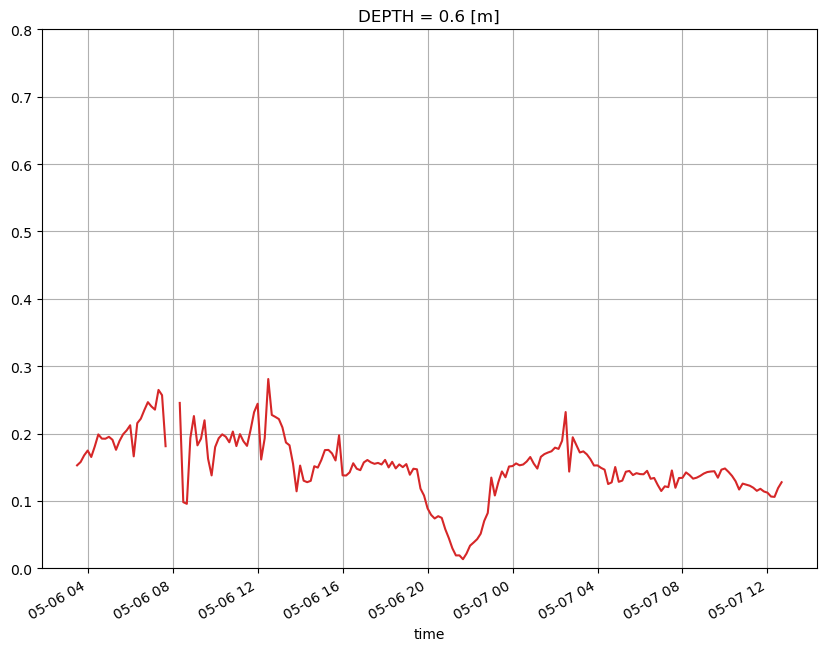

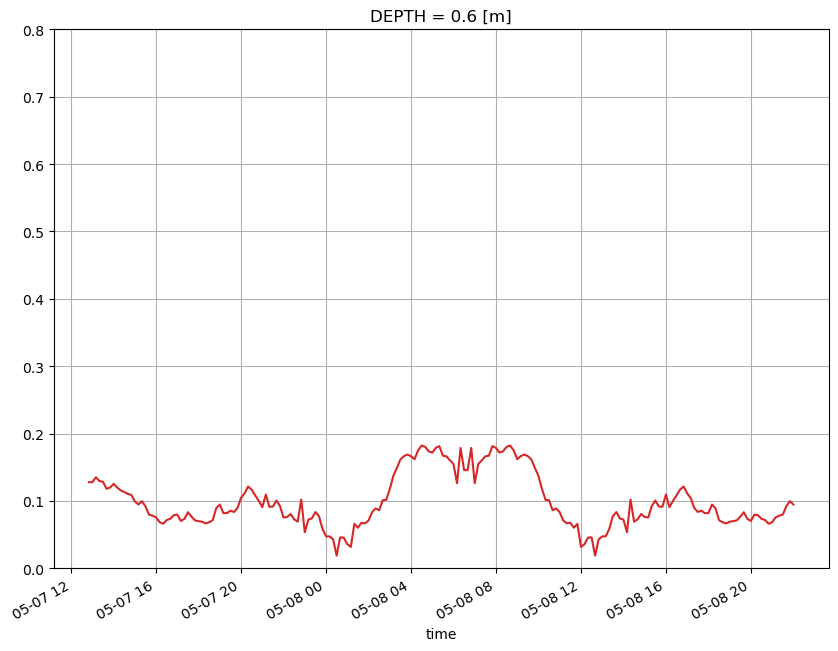

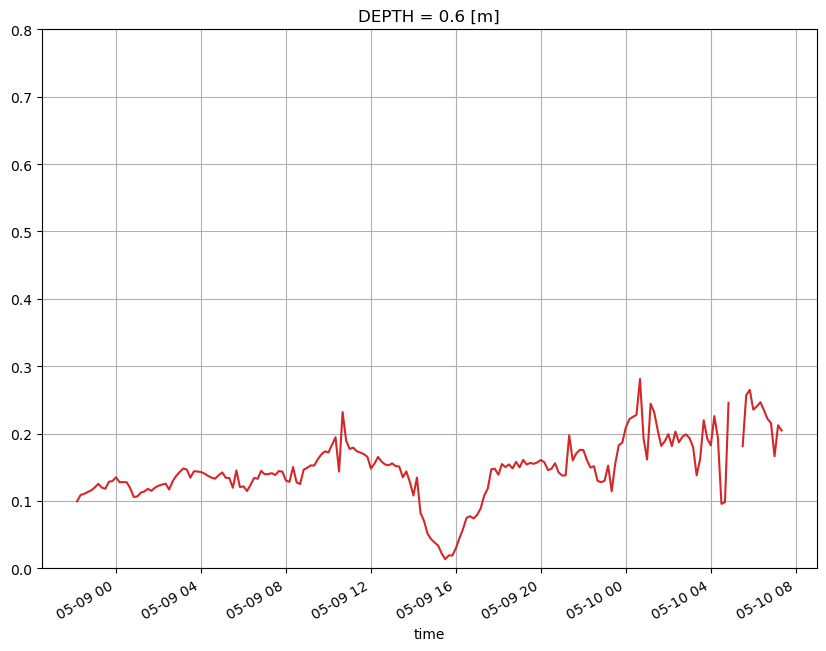

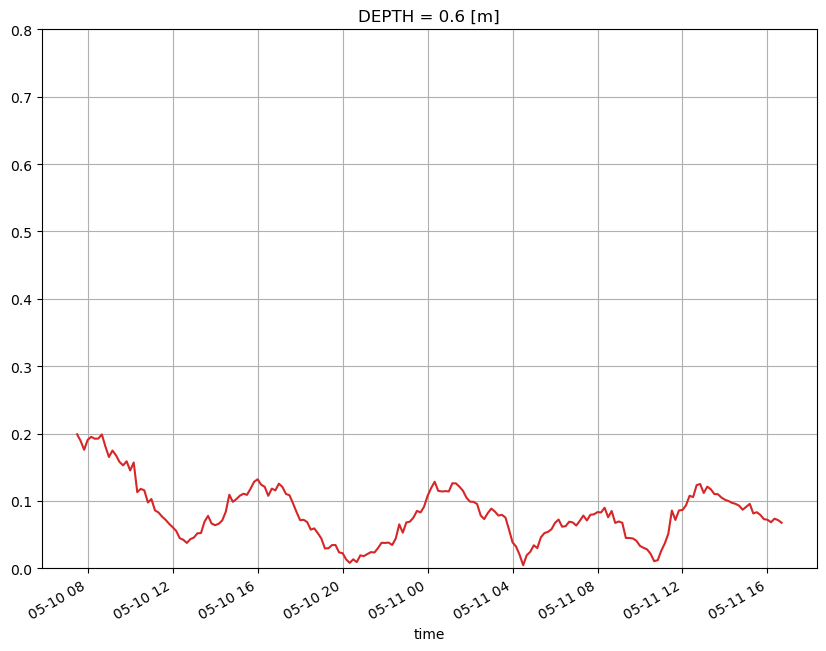

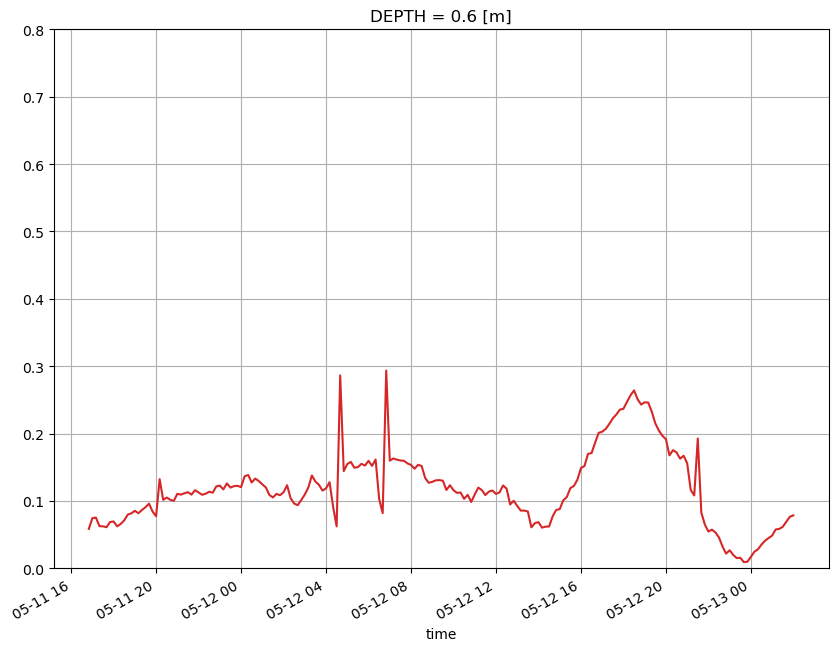

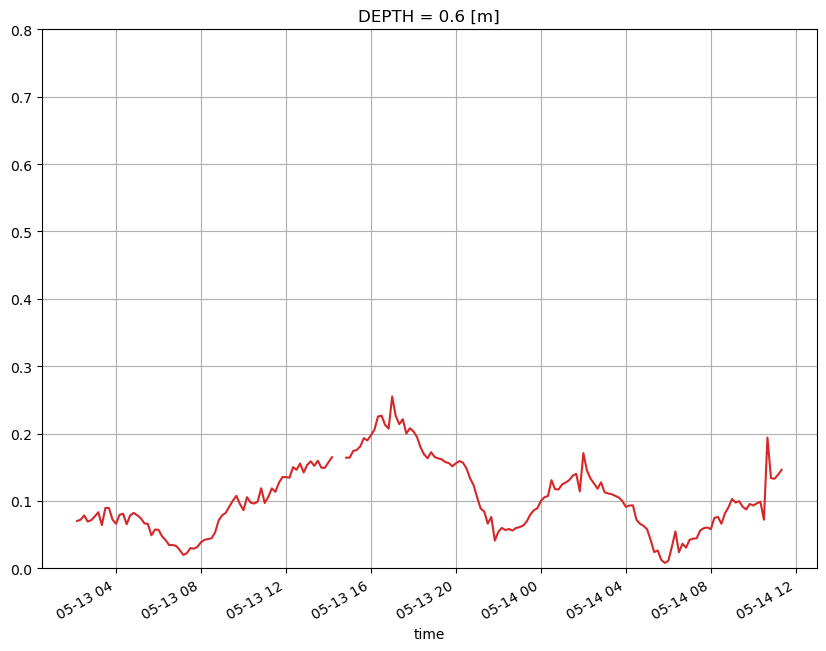

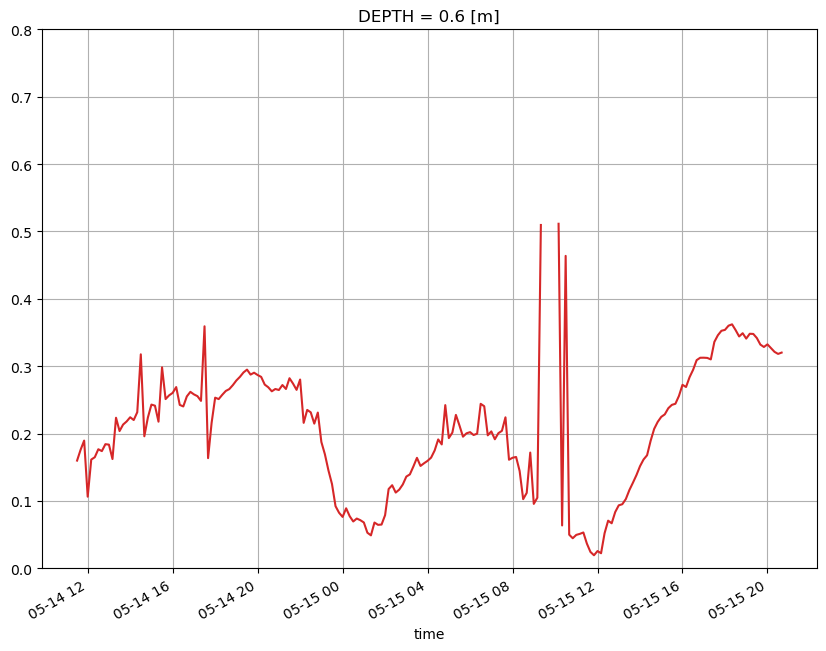

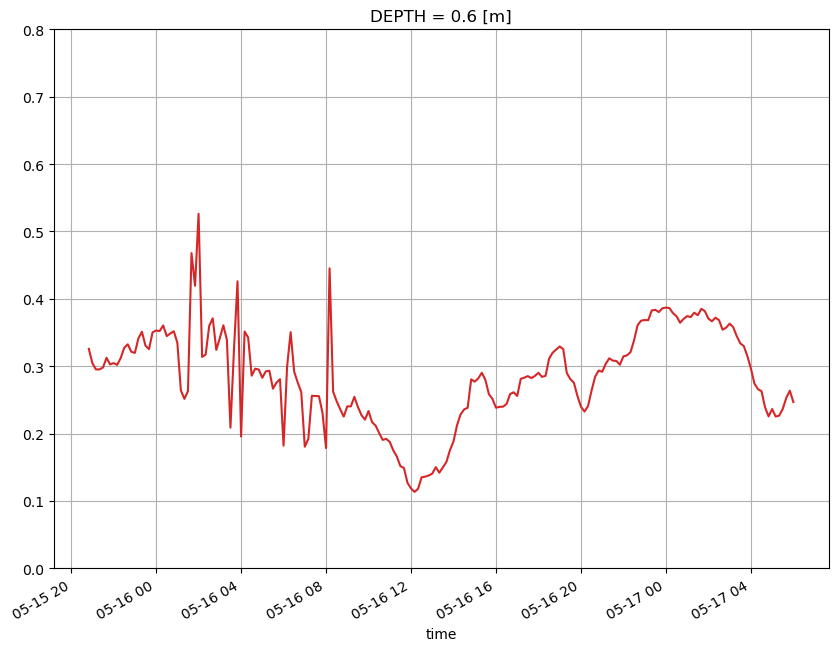

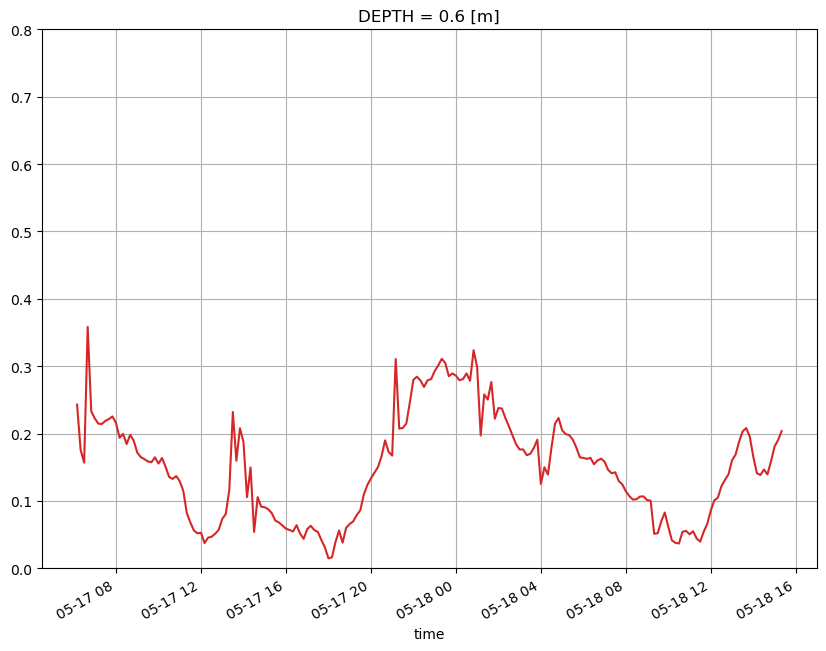

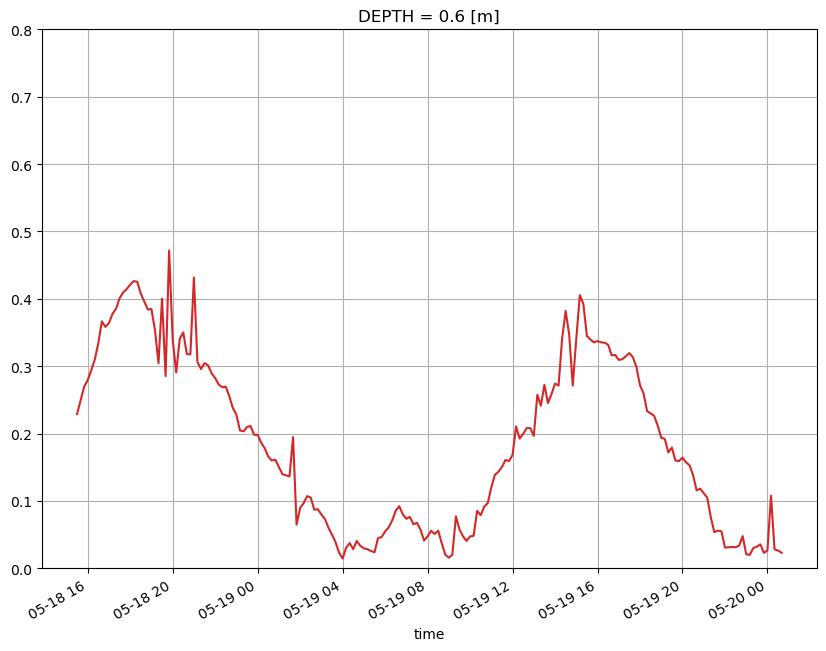

In [38]:
# to visualize data gaps:
for ii in range(0, int(np.floor(len(abs_vel_new)/200.))):
    abs_vel_new[(ii*200):((ii+1)*200)].plot(figsize=(10,7), c='C3')
    plt.ylim([0,0.8])
    plt.grid()

## 2.5. Smoothing

### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [39]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
ds03 = ds03.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [40]:
ds04 = ds03.interpolate_na(dim='time', method="pchip") 
# Pchip : cubic with splines interp. (Dani find ref.)

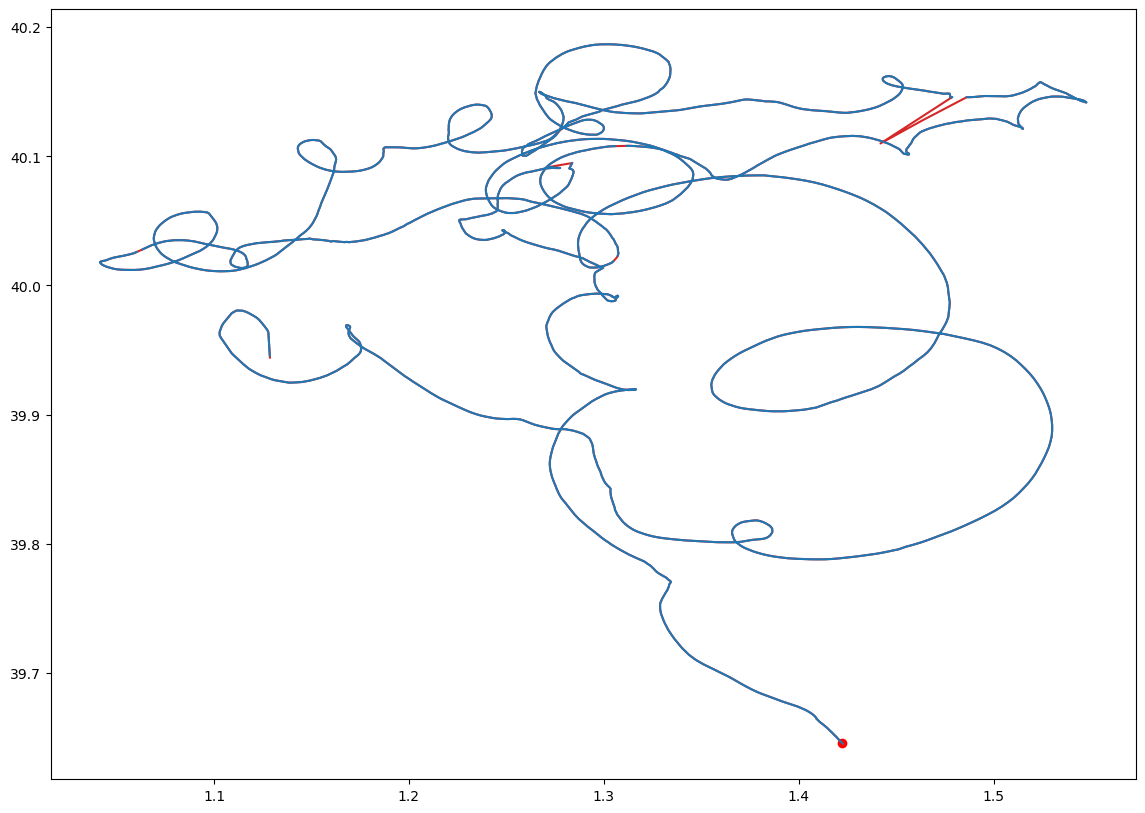

In [41]:
plt.figure(figsize=(14,10))
plt.plot(ds04.LON, ds04.LAT, 'C3')
plt.plot(ds03.LON, ds03.LAT)
plt.scatter(ds04.LON[1], ds04.LAT[1], c='r')

### 2.5.2. Applying smoothing
To remove small scale noise and any remaining spikes.

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

# %%%%%%%%%%%
# Testing with abs_vel:

In [42]:
abs_vel_new = (ds04.U**2 + ds04.V**2)**0.5

In [43]:
ii = 0

### Trying different window sizes:
https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.signal.hann.html 

signal.hamming(n) ; n = number of points. If we want a 30 mins window, n=3.

In [44]:
abs_vel_new.size

3414

In [45]:
# Apply the Hamming
    
variable = abs_vel_new[(ii*200):((ii+1)*200)]

window = signal.windows.hamming(3)
filtered_variable_03 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hamming(6)
filtered_variable_06 = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hamming(12)
filtered_variable_12 = signal.convolve(variable, window, mode='same') / np.sum(window)


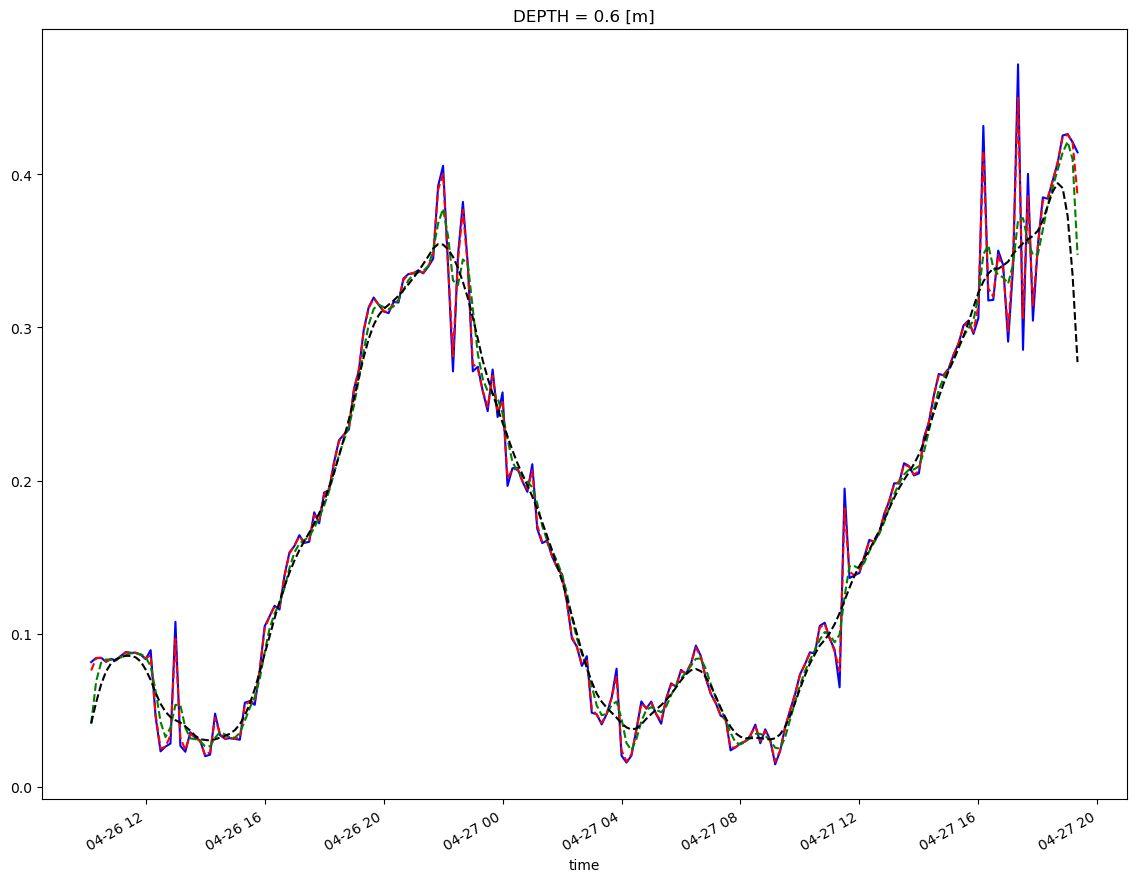

In [46]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06, '--g')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12, '--k')

# --> need to see how the borders were fixed (Laura check)

# --> 12 looks best (2h window)

## Checking out Hann window: (equivalent to Hanning??)

In [47]:
window = signal.windows.hann(3)
filtered_variable_03_hann = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hann(6)
filtered_variable_06_hann = signal.convolve(variable, window, mode='same') / np.sum(window)
window = signal.windows.hann(12)
filtered_variable_12_hann = signal.convolve(variable, window, mode='same') / np.sum(window)

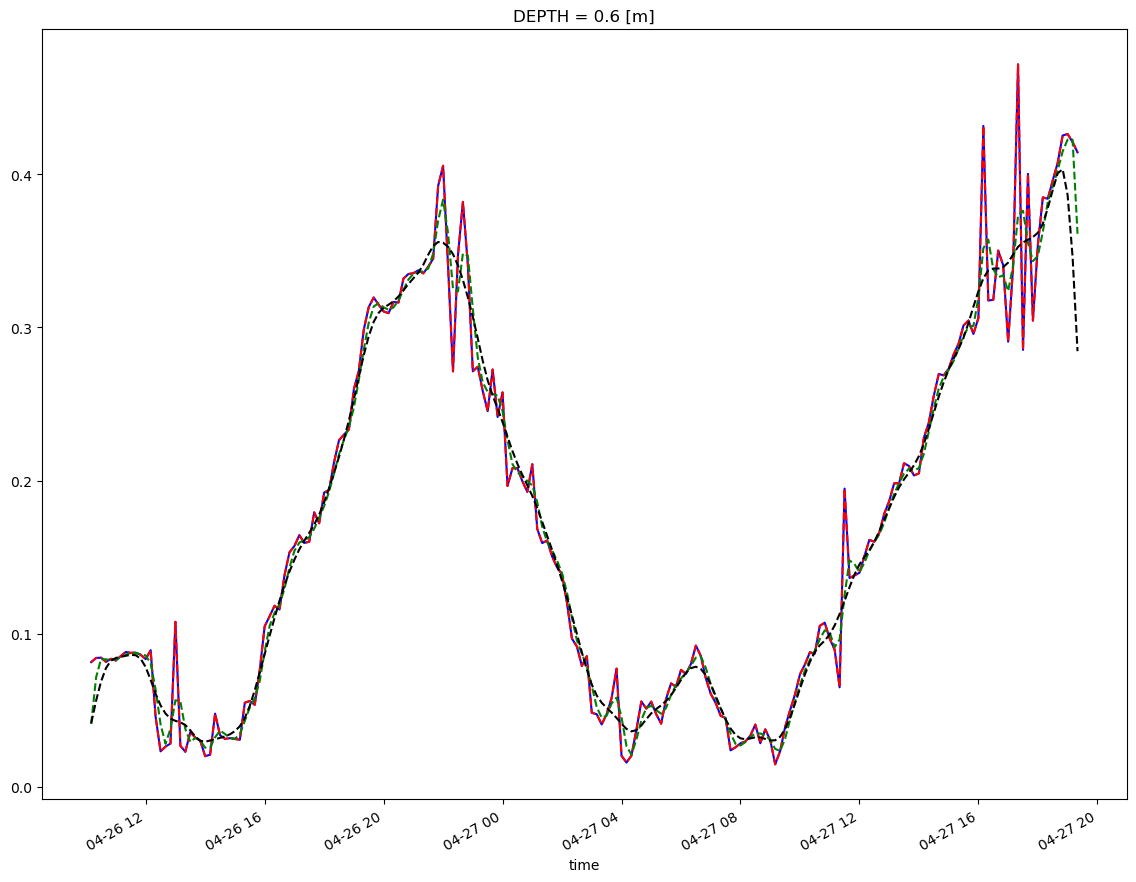

In [48]:
variable.plot(c='b',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_03_hann, '--r')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_06_hann, '--g')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12_hann, '--k')

# --> difference?

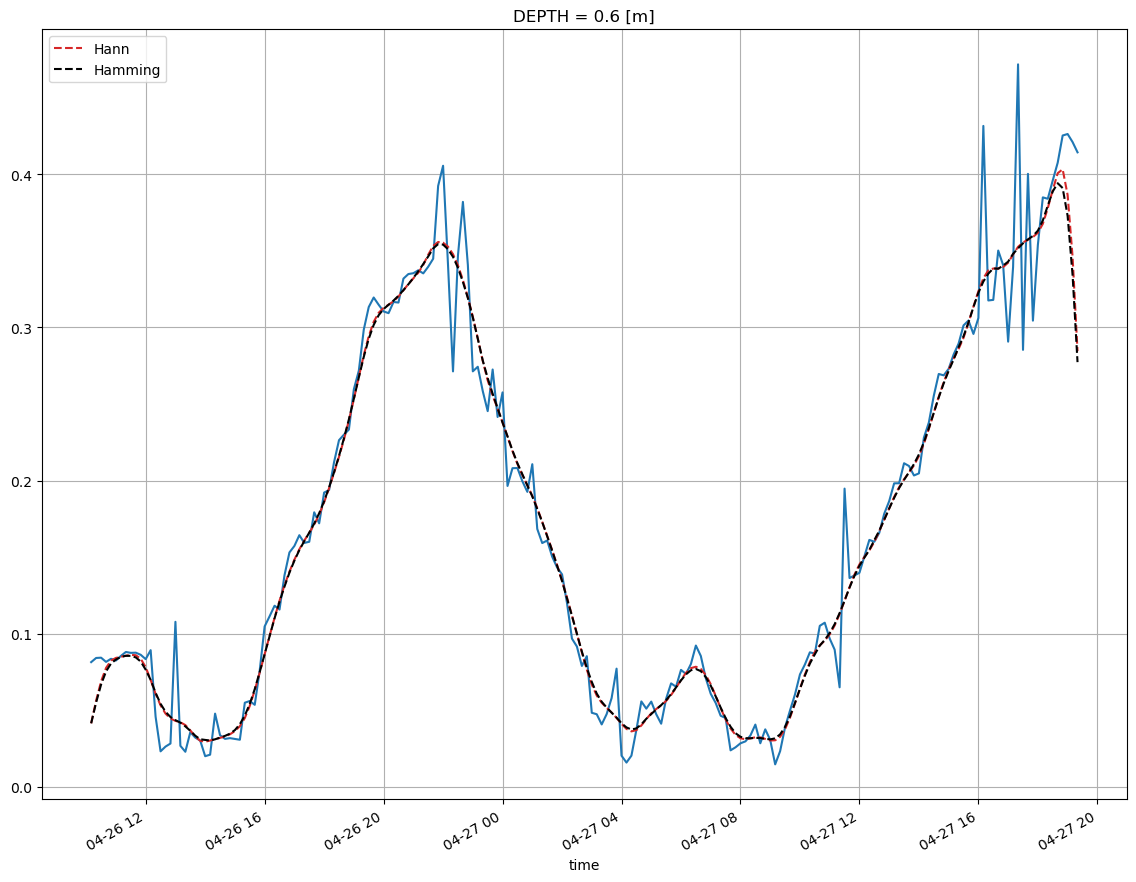

In [49]:
variable.plot(c='C0',figsize=(14,10))
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12_hann, '--', c='C3', label='Hann')
plt.plot(ds04.time[(ii*200):((ii+1)*200)], filtered_variable_12, '--k', label='Hamming')
plt.grid()
plt.legend()

# --> not much differences, only on peaks

# %%%%%%%%%%%


#### Smoothing on lon and lat:

In [50]:
ds05 = ds04.copy()

In [51]:
ds05

<xarray.Dataset>
Dimensions:     (time: 3414)
Coordinates:
    DEPTH       float64 0.6
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-20T03:0...
Data variables:
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.64 39.65 39.65 39.65 ... 39.95 39.95 39.94
    LON         (time) float64 1.423 1.422 1.422 1.421 ... 1.129 1.129 1.129
    U           (time) float64 -0.0263 -0.02979 -0.03264 ... -0.02979 -0.0263
    V           (time) float64 -0.07705 -0.07869 -0.07776 ... -0.07869 -0.07705
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [52]:
# ds05["LON"] = ds04.LON.rolling(time=12, center=True).median()
# ds05["LAT"] = ds04.LAT.rolling(time=12, center=True).median()

window = signal.windows.hamming(12) # 2 hours (12 points) 

ds05["LON"][:] = signal.convolve(ds04.LON.values, window, mode='same') / np.sum(window)
ds05["LAT"][:] = signal.convolve(ds04.LAT, window, mode='same') / np.sum(window)


In [53]:
ds05

<xarray.Dataset>
Dimensions:     (time: 3414)
Coordinates:
    DEPTH       float64 0.6
  * time        (time) datetime64[ns] 2023-04-26T10:10:00 ... 2023-05-20T03:0...
Data variables:
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 19.82 26.29 31.83 35.81 ... 36.09 32.07 26.49
    LON         (time) float64 0.7111 0.9429 1.141 1.284 ... 1.019 0.9059 0.7482
    U           (time) float64 -0.0263 -0.02979 -0.03264 ... -0.02979 -0.0263
    V           (time) float64 -0.07705 -0.07869 -0.07776 ... -0.07869 -0.07705
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE001 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE001 in FaSt-...
    summary:                             Deployment of IME-CARTHE001 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

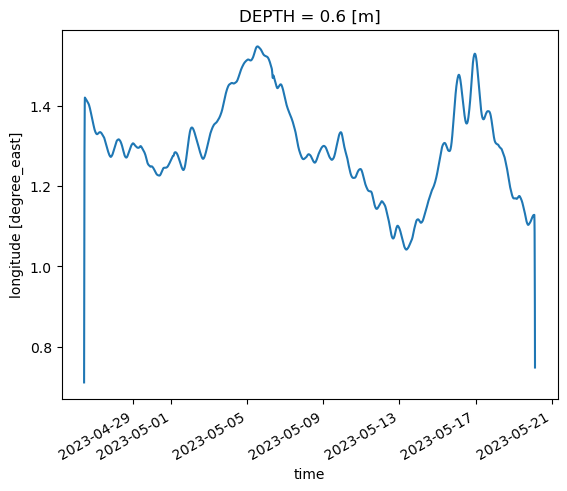

In [54]:
ds05.LON.plot()

# --> weird dips in LON at extremes --> to be fixed (mentioned above)

# Recalculate U and V:

In [55]:
ufor, vfor, uvabsfor    = latlon2uv_dir(ds05['LAT'], ds05['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback, uvabsback = latlon2uv_dir(ds05['LAT'], ds05['LON'], temp_res, 'back')

In [56]:
# Add variables to the dataset
ds05 = ds05.assign(U=(ufor+uback)*0.5)
ds05 = ds05.assign(V=(vfor+vback)*0.5)
ds05 = ds05.assign(UV=(uvabsfor+uvabsback)*0.5)
print(list(ds05.keys()))

['BAT_STATUS', 'LAT', 'LON', 'U', 'V', 'UV']


# Comparing abs. vel before and after smoothing:

* Before:

In [57]:
ufor, vfor, uvabsfor   = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback, uvabsback = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'back')

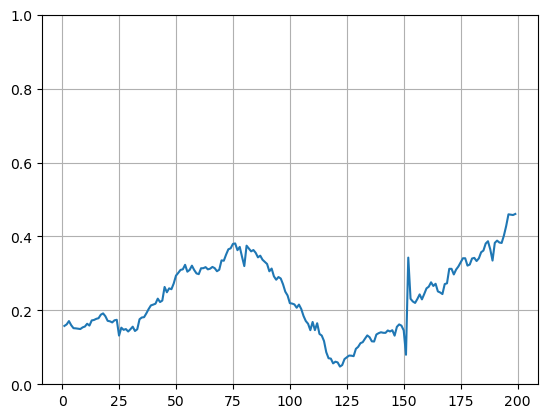

In [58]:
plt.plot(uvabsfor[0:200])
plt.ylim([0, 1])
plt.grid()

* After:

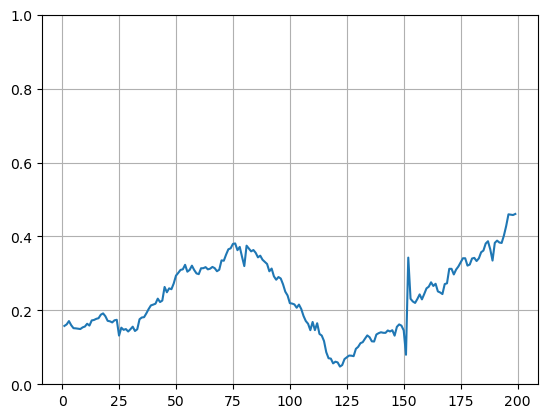

In [59]:
plt.plot(uvabsfor[0:200])
plt.ylim([0, 1])
plt.grid()

# Battery:

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

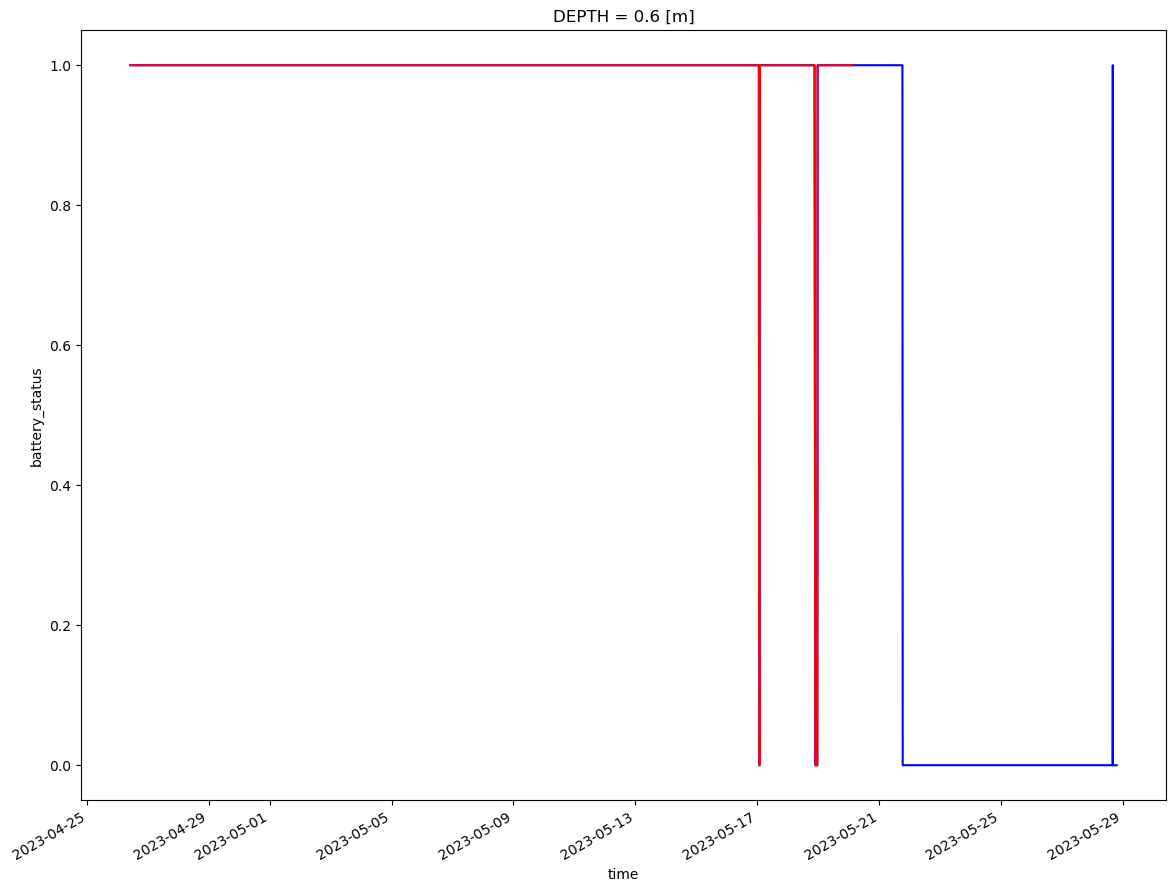

In [60]:
ds.BAT_STATUS.plot(figsize=(14,10), c='b')
ds05.BAT_STATUS.plot(c='r')

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later

# 3. Saving data

In [61]:
rootdir = '../../../'

In [62]:
outdir = 'data/drifters/L1_IMEDEA/'

In [63]:
fname = url_drifter.split('/')[0] + '.nc'

In [64]:
ds05.to_netcdf(rootdir + outdir + fname)

In [65]:
!ls ../../../data/drifters/L1_IMEDEA/

drifter_carthe006-ime_carthe001.nc drifter_carthe016-ime_carthe011.nc
drifter_carthe007-ime_carthe002.nc drifter_carthe017-ime_carthe012.nc
drifter_carthe008-ime_carthe003.nc drifter_carthe018-ime_carthe013.nc
drifter_carthe009-ime_carthe004.nc drifter_carthe019-ime_carthe014.nc
drifter_carthe010-ime_carthe005.nc drifter_carthe020-ime_carthe015.nc
drifter_carthe011-ime_carthe006.nc drifter_carthe021-ime_carthe016.nc
drifter_carthe012-ime_carthe007.nc drifter_carthe022-ime_carthe017.nc
drifter_carthe013-ime_carthe008.nc drifter_carthe023-ime_carthe018.nc
drifter_carthe014-ime_carthe009.nc drifter_carthe024-ime_carthe019.nc
drifter_carthe015-ime_carthe010.nc drifter_carthe025-ime_carthe020.nc


# 4. Plotting outputs

In [76]:
map_extent=[-0.3, 7.9, 37.9, 41.5]
fsize=14


## (UNTIL WINDOW BORDERS FIXED IGNORE FIRST AND LAST POINTS)

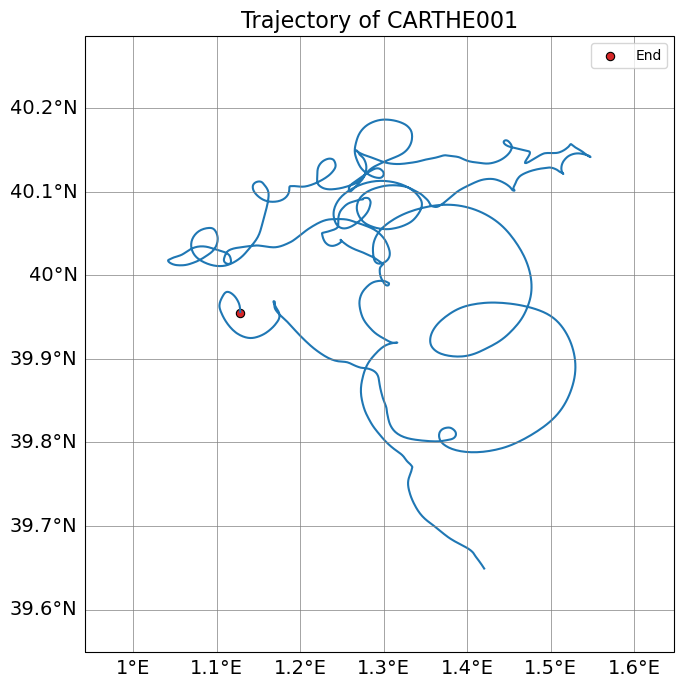

In [107]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds05.LON[6:-7], ds05.LAT[6:-7], transform=ccrs.PlateCarree(), c='C0') 
ax1.scatter(ds05.LON[-7], ds05.LAT[-7], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='End')

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
ax1.set_title('Trajectory of ' + ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

plt.show()

## Velocity:

In [102]:
thresa = .1
map_extent = [ds05.LON[6:-7].min().values - thresa, ds05.LON[6:-7].max().values + thresa, ds05.LAT[6:-7].min().values - thresa, ds05.LAT[6:-7].max().values + thresa]

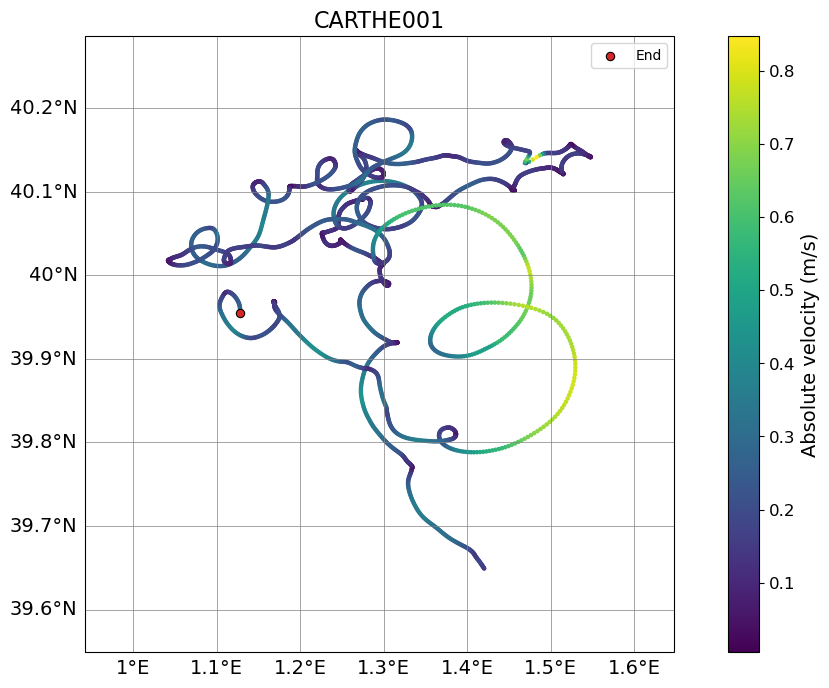

In [106]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

cc = ax1.scatter(ds05.LON[6:-7], ds05.LAT[6:-7], s=5, c=ds05.UV[6:-7], transform=ccrs.PlateCarree())
ax1.scatter(ds05.LON[-7], ds05.LAT[-7], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='End')
cbar = plt.colorbar(cc)
cbar_label = r'Absolute velocity (m/s)'
cbar.ax.tick_params(labelsize=fsize-2)
cbar.ax.set_ylabel(cbar_label, fontsize=fsize)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
ax1.set_title(ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

plt.show()